In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import seaborn.objects as so
import numpy as np
from lqg import xcorr
import arviz as az

from jax import random, jit

plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.models.multisensory import MultisensoryDelayModel, UnisensoryDelayModel
from cppp.load import preprocess_multisensory_data, load_multisensory_data


## Load data

In [111]:

df = load_multisensory_data(base_path="../data")
df.head()

print(df["participant"].unique())

Multisensory DataFrame loaded from ../data/multisensory/df_all_phases_all_participants.csv with shape: (492343, 14)
[135033060 173058413 177196795 182095555 212056115 330954011 524048600
 544725341 644801403 657093471 714671738 741917610 765738475 799755310
 802096684 879521247 891444214 910949717 918338248]


In [112]:
df.columns

Index(['participant', 'perturb', 'session', 'phase', 'trial_number', 'type',
       'vis_noise', 'cursor_offset', 'time', 'lefty_pos', 'leftx_pos',
       'righty_pos', 'rightx_pos', 'cursory_pos'],
      dtype='object')

In [113]:
for condition in df["type"].unique():
    for vis_noise in df["vis_noise"].unique():
        print(condition, vis_noise)
        data = preprocess_multisensory_data(
                        df, participant=765738475, condition=condition, vis_noise=vis_noise
                    )
        print(data.shape)

vis 1
(8, 166, 2)
vis 2
(8, 166, 2)
multi 1
(8, 166, 2)
multi 2
(8, 166, 2)
prop 1
(8, 166, 2)
prop 2
(8, 166, 2)


## Joint model

In [114]:
# participant = 765738475
participant = 135033060
# participant = 177196795
seed = 7453
# participant = 802096684
models = {model_name: az.from_netcdf(
                f"../results/multisensory-mcmc-{participant}_1_2_{seed}_1000_2500_4_{model_name}.nc"
            )
            for model_name in ["optimal", "no_integration", "equal_integration"]}

# TODO: rhats

                   rank     elpd_loo     p_loo  elpd_diff        weight  \
no_integration        0 -2583.449249  3.696960   0.000000  1.000000e+00   
optimal               1 -2591.742371  4.186401   8.293121  3.333445e-13   
equal_integration     2 -2623.226959  5.026245  39.777710  0.000000e+00   

                          se       dse  warning scale  
no_integration     66.469576  0.000000    False   log  
optimal            66.594163  2.259601    False   log  
equal_integration  66.354459  5.675348    False   log  
                   rank     elpd_loo     p_loo  elpd_diff        weight  \
no_integration        0 -2433.257538  2.064911   0.000000  1.000000e+00   
optimal               1 -2435.467255  2.089264   2.209717  1.486034e-13   
equal_integration     2 -2485.482880  4.988495  52.225342  0.000000e+00   

                          se        dse  warning scale  
no_integration     43.898427   0.000000    False   log  
optimal            43.797933   0.885381    False   log  
equ

/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


                   rank     elpd_loo      p_loo  elpd_diff    weight  \
optimal               0 -1799.047180  11.977432   0.000000  0.555539   
equal_integration     1 -1799.676178  11.001358   0.628998  0.444461   
no_integration        2 -1801.216599  12.045212   2.169418  0.000000   

                          se       dse  warning scale  
optimal            63.502236  0.000000     True   log  
equal_integration  58.690954  8.655239    False   log  
no_integration     62.799358  1.957572     True   log  
                   rank     elpd_loo     p_loo  elpd_diff        weight  \
no_integration        0 -2463.747192  4.261597   0.000000  9.746991e-01   
optimal               1 -2465.648621  4.432037   1.901428  1.921742e-15   
equal_integration     2 -2484.731140  6.813843  20.983948  2.530086e-02   

                          se       dse  warning scale  
no_integration     41.836056  0.000000    False   log  
optimal            41.911591  0.345075    False   log  
equal_integration 

/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-propri

                   rank     elpd_loo      p_loo  elpd_diff        weight  \
no_integration        0 -2478.883621  10.104355   0.000000  9.671619e-01   
optimal               1 -2479.263641  10.310837   0.380020  3.283809e-02   
equal_integration     2 -2482.161880  14.480453   3.278259  2.331468e-15   

                           se       dse  warning scale  
no_integration     109.291854  0.000000     True   log  
optimal            108.390352  0.916655     True   log  
equal_integration  108.903072  1.448089     True   log  
                   rank     elpd_loo     p_loo  elpd_diff        weight  \
no_integration        0 -2382.862305  2.543121   0.000000  1.000000e+00   
optimal               1 -2384.125153  2.563019   1.262848  1.165734e-15   
equal_integration     2 -2385.217743  3.024963   2.355438  0.000000e+00   

                          se       dse  warning scale  
no_integration     79.330116  0.000000    False   log  
optimal            78.712402  0.634147    False   log 

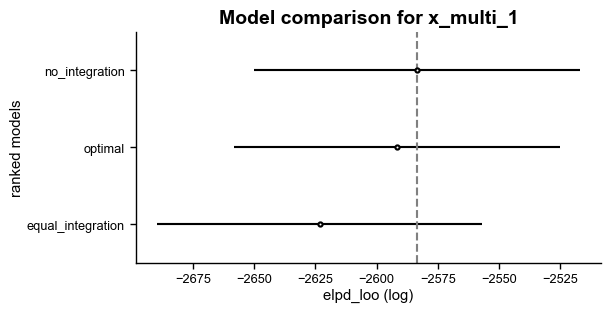

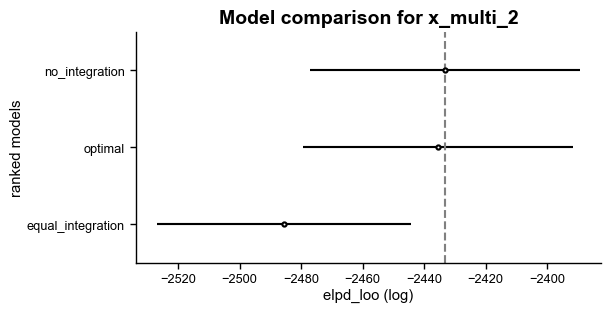

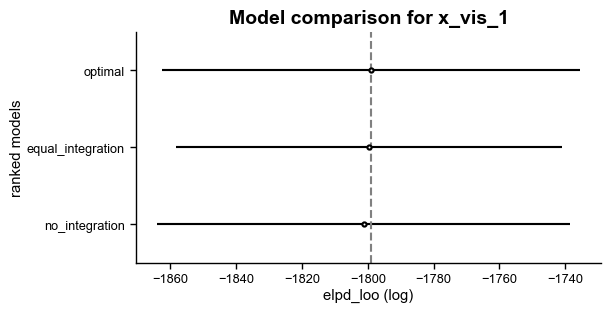

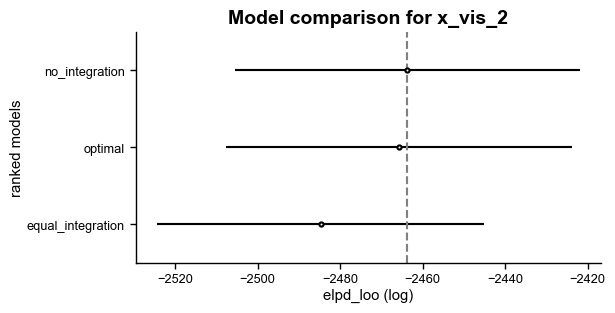

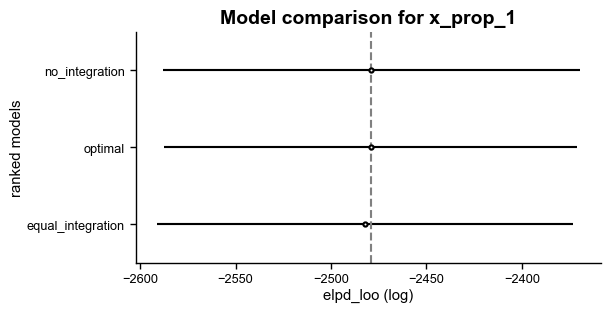

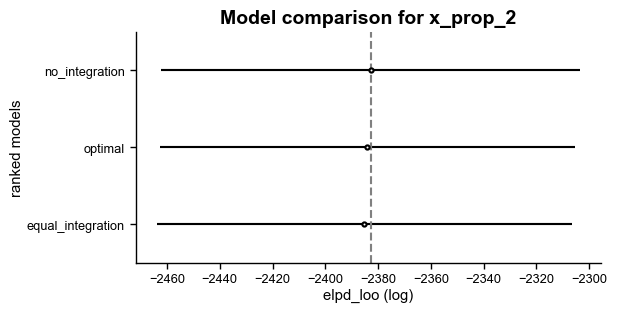

In [115]:
for var_name in ["x_multi_1", "x_multi_2", "x_vis_1", "x_vis_2", "x_prop_1", "x_prop_2"]:

    comp_df = az.compare(models, var_name=var_name)
    print(comp_df)
    axes = az.plot_compare(comp_df=comp_df)
    axes.set_title(f"Model comparison for {var_name}")

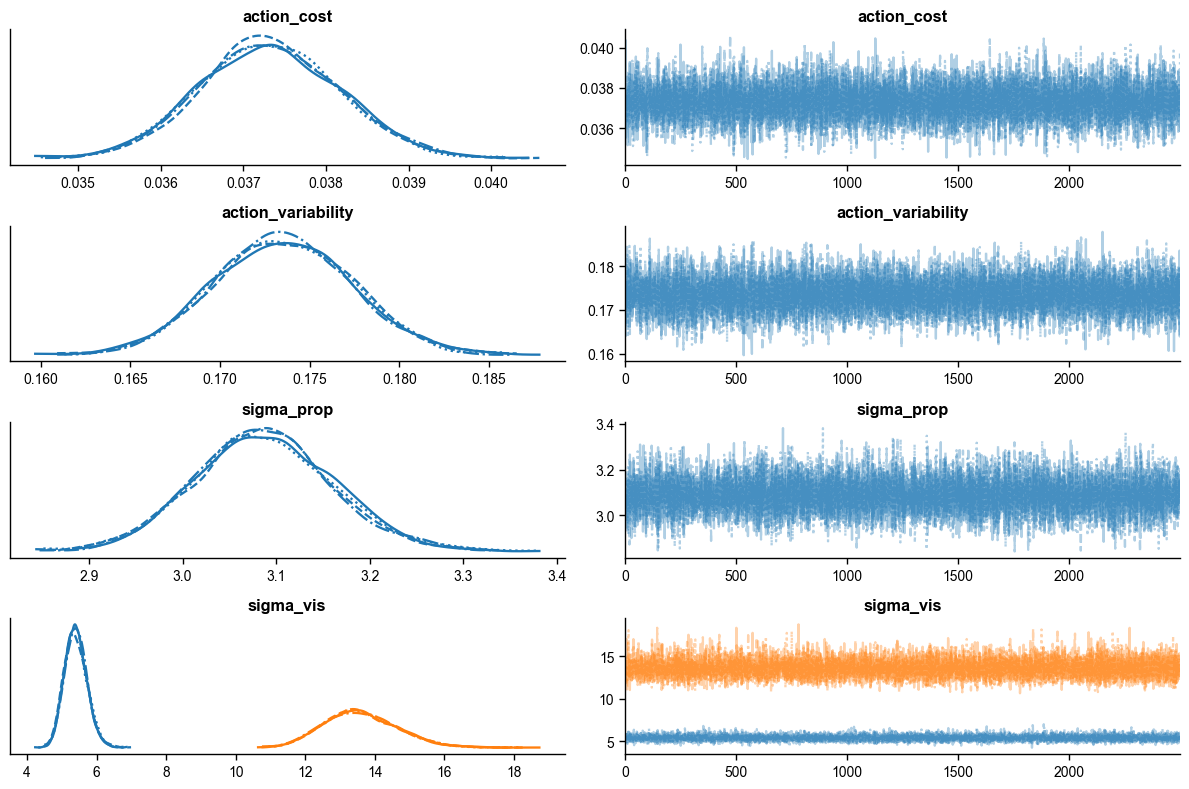

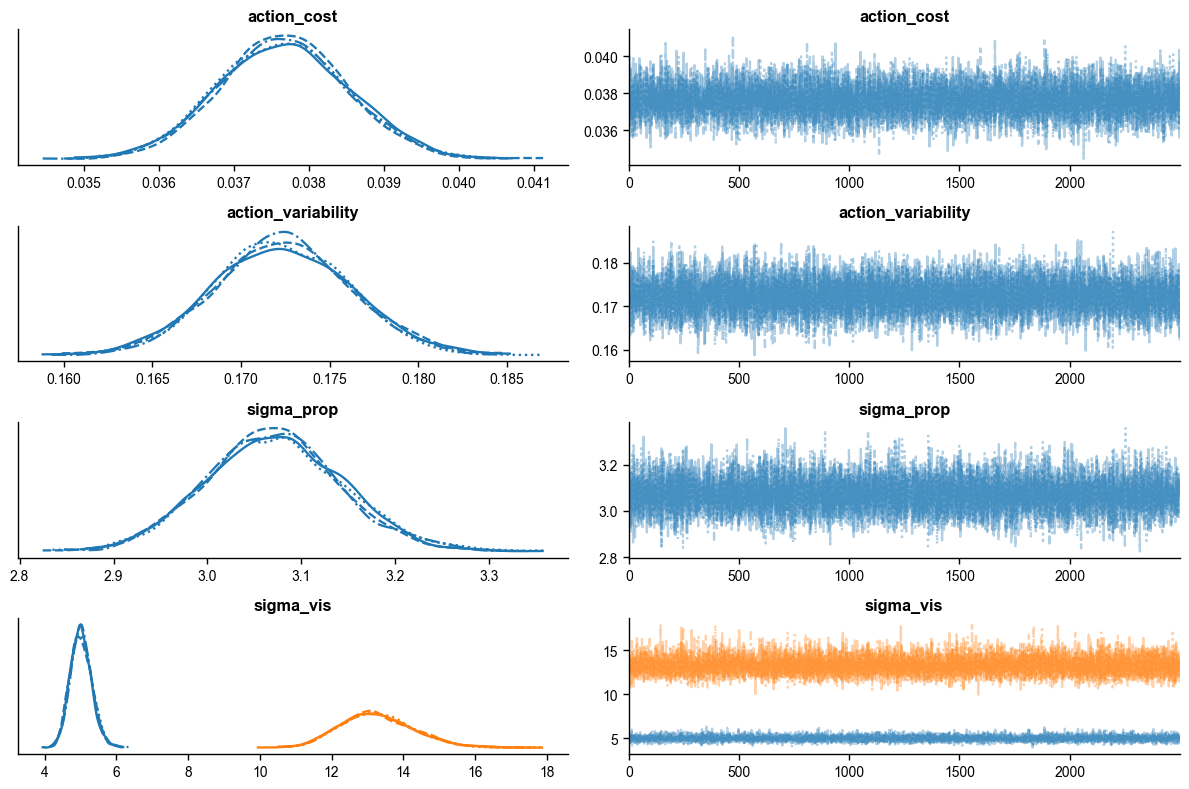

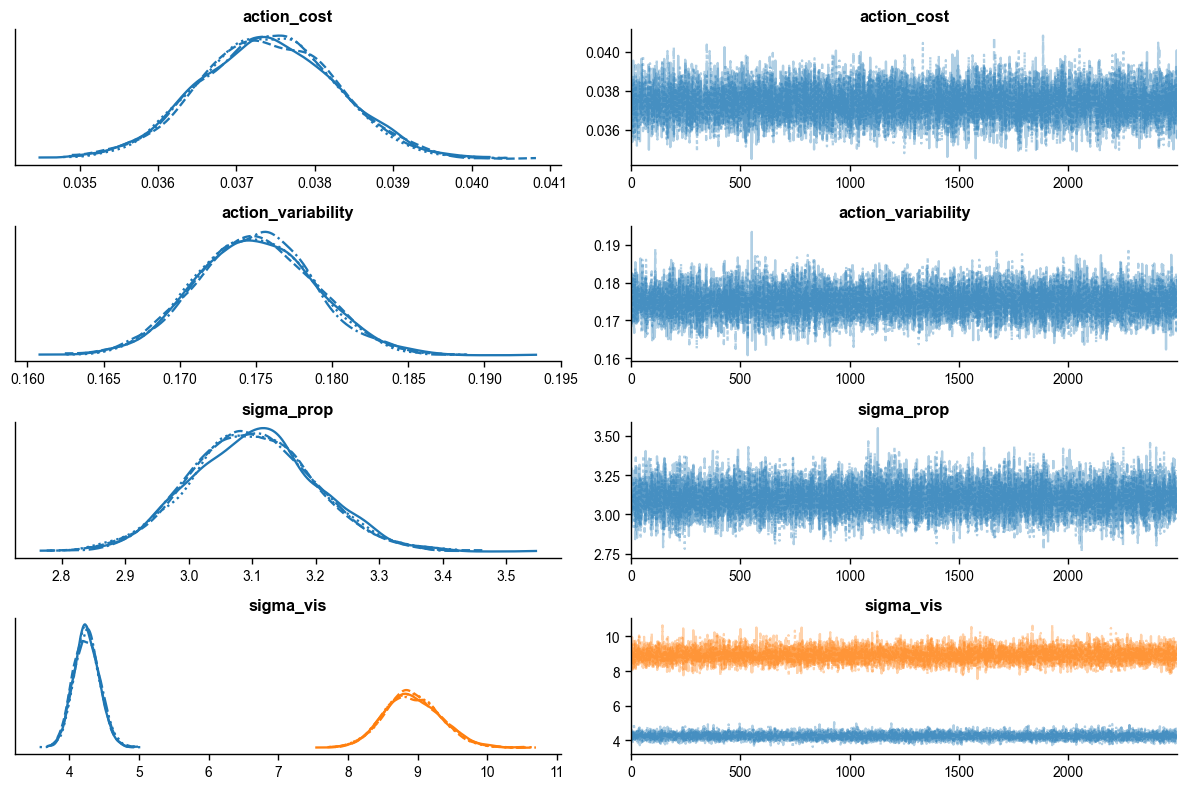

In [116]:
for name, model in models.items():
    az.plot_trace(model)
    plt.tight_layout()

Condition: multi, Vis Noise: 1
{'action_cost': 0.037, 'action_variability': 0.174, 'sigma_prop': 3.087, 'sigma_vis[0]': 5.402, 'sigma_vis[1]': 13.603}
(4, 2500, 101)
Condition: multi, Vis Noise: 2
{'action_cost': 0.037, 'action_variability': 0.174, 'sigma_prop': 3.087, 'sigma_vis[0]': 5.402, 'sigma_vis[1]': 13.603}
(4, 2500, 101)
Condition: vis, Vis Noise: 1
{'action_cost': 0.037, 'action_variability': 0.174, 'sigma_prop': 3.087, 'sigma_vis[0]': 5.402, 'sigma_vis[1]': 13.603}
(4, 2500, 101)
Condition: vis, Vis Noise: 2
{'action_cost': 0.037, 'action_variability': 0.174, 'sigma_prop': 3.087, 'sigma_vis[0]': 5.402, 'sigma_vis[1]': 13.603}
(4, 2500, 101)
Condition: prop, Vis Noise: 1
{'action_cost': 0.037, 'action_variability': 0.174, 'sigma_prop': 3.087, 'sigma_vis[0]': 5.402, 'sigma_vis[1]': 13.603}
(4, 2500, 101)
Condition: prop, Vis Noise: 2
{'action_cost': 0.037, 'action_variability': 0.174, 'sigma_prop': 3.087, 'sigma_vis[0]': 5.402, 'sigma_vis[1]': 13.603}
(4, 2500, 101)
Condition:

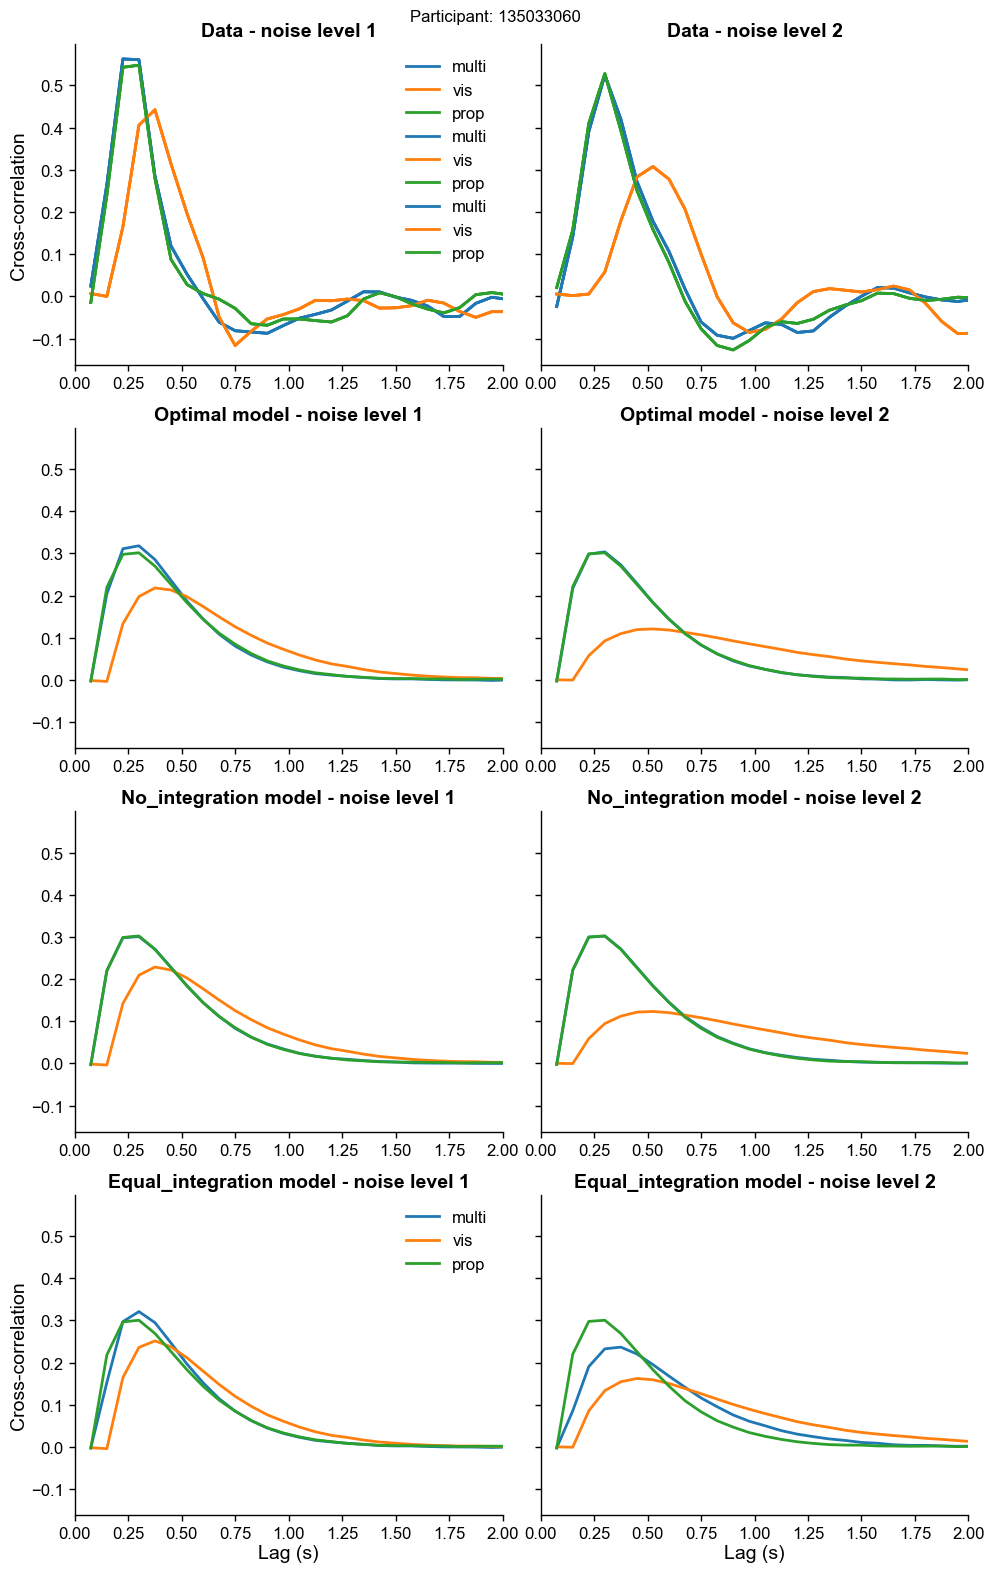

In [117]:
import jax.numpy as jnp

delays = {"prop": 1, "vis": 2}

f, ax = plt.subplots(4, 2, figsize=(10, 16), sharey=True)

for k, (model_name, model) in enumerate(models.items()):
    summary = az.summary(model)
    # get posterior mean
    posterior_mean = summary["mean"].to_dict()
    for i, condition in enumerate(["multi", "vis", "prop"]):

        for j, vis_noise in enumerate([1, 2]):
            # preprocess the data for this participant, condition, and noise level
            data = preprocess_multisensory_data(
                    df, participant=participant, condition=condition, vis_noise=vis_noise
                )

            
            print(f"Condition: {condition}, Vis Noise: {vis_noise}")
            print(posterior_mean)

            # # create model with posterior mean parameters (note that we have to rename the sigmas parameters for the multisensory model)
            # if condition == "multi":
            #     if model_name == "optimal":
            #         model = MultisensoryDelayModel(
            #             process_noise=1.2,
            #             sigmas=[posterior_mean["sigma_prop"], posterior_mean[f"sigma_vis[{vis_noise - 1}]"]],
            #             action_variability=posterior_mean["action_variability"],
            #             action_cost=posterior_mean["action_cost"],
            #             delays=[delays["prop"], delays["vis"]],
            #             dt=0.075,
            #             T=data.shape[1],
            #         )
            #     elif model_name == "no_integration":
            #         model = MultisensoryDelayModel(
            #             process_noise=1.2,
            #             sigmas=[posterior_mean["sigma_prop"]],
            #             action_variability=posterior_mean["action_variability"],
            #             action_cost=posterior_mean["action_cost"],
            #             delays=[delays["prop"]],
            #             dt=0.075,
            #             T=data.shape[1],
            #         )
            #     elif model_name == "equal_integration":
            #         sigma = jnp.sqrt((posterior_mean["sigma_prop"] ** 2 + posterior_mean[f"sigma_vis[{vis_noise - 1}]"] ** 2) / 2)
            #         model = MultisensoryDelayModel(
            #             process_noise=1.2,
            #             sigmas=[sigma, sigma],
            #             action_variability=posterior_mean["action_variability"],
            #             action_cost=posterior_mean["action_cost"],
            #             delays=[delays["prop"], delays["vis"]],
            #             dt=0.075,
            #             T=data.shape[1],
            #         )
            # else:
            #     delay = delays[condition]
            #     model = UnisensoryDelayModel(
            #         process_noise=1.2,
            #         sigma=posterior_mean[f"sigma_{condition}"] if condition == "prop" else posterior_mean[f"sigma_vis[{vis_noise - 1}]"],
            #         action_variability=posterior_mean["action_variability"],
            #         action_cost=posterior_mean["action_cost"],
            #         delay=delay,
            #         dt=0.075,
            #         T=data.shape[1],
            #     )

            # # TODO: generate prediction for multisensory condition from unisensory model fits

            # # simulate data from the model and compute cross-correlation of velocities for both the simulated data and the real data
            # sim_data = model.simulate(rng_key=random.PRNGKey(0), n=100)

            sim_data = model.posterior_predictive[
            f"x_{condition}_{vis_noise}"
        ]# .mean(axis=(0, 1))
            sim_vels = np.diff(sim_data, axis=-2)
            lags, sim_correls = xcorr(sim_vels[..., 1], sim_vels[..., 0], maxlags=50)
            print(sim_correls.shape)

            
            vels = np.diff(data, axis=1)
            lags, correls = xcorr(vels[:, :, 1], vels[:, :, 0], maxlags=50)

            # plot the cross-correlations for the real data and the simulated data
            ax[0, j].plot(
                lags[51:] * 0.075, correls.mean(axis=0)[51:], label=f"{condition}", color=f"C{i}"
            )
            ax[k+1, j].plot(
                lags[51:] * 0.075, sim_correls.mean(axis=(0, 1))[51:], label=f"{condition}", color=f"C{i}"
            )

            ax[0, j].set_xlim(0, 2)
            ax[k+1, j].set_xlim(0, 2)

            ax[0, j].set_title(f"Data - noise level {vis_noise}")
            ax[k+1, j].set_title(f"{model_name.capitalize()} model - noise level {vis_noise}")

ax[k+1, 0].set_xlabel("Lag (s)")
ax[k+1, 1].set_xlabel("Lag (s)")
ax[0, 0].set_ylabel("Cross-correlation")
ax[k+1, 0].set_ylabel("Cross-correlation")

ax[0, 0].legend()
ax[k+1, 0].legend()
f.suptitle(f"Participant: {participant}")
f.tight_layout()

## Simulate offset phase

In [118]:
# turn arviz model into dict of samples for each variable
def get_samples(model):
    return {var_name: model.posterior[var_name].values for var_name in model.posterior}


In [119]:
models["optimal"].posterior

<xarray.Dataset> Size: 220kB
Dimensions:             (chain: 4, draw: 2500, sigma_vis_dim_0: 2)
Coordinates:
  * chain               (chain) int64 32B 0 1 2 3
  * draw                (draw) int64 20kB 0 1 2 3 4 ... 2495 2496 2497 2498 2499
  * sigma_vis_dim_0     (sigma_vis_dim_0) int64 16B 0 1
Data variables:
    action_cost         (chain, draw) float32 40kB 0.03836 0.04037 ... 0.0397
    action_variability  (chain, draw) float32 40kB 0.1816 0.1769 ... 0.1734
    sigma_prop          (chain, draw) float32 40kB 3.108 3.189 ... 3.141 3.104
    sigma_vis           (chain, draw, sigma_vis_dim_0) float32 80kB 5.458 ......
Attributes:
    created_at:                 2026-03-23T21:53:47.957000+00:00
    arviz_version:              0.22.0
    inference_library:          numpyro
    inference_library_version:  0.18.0

In [120]:
df

,participant,perturb,session,phase,trial_number,type,vis_noise,cursor_offset,time,lefty_pos,leftx_pos,righty_pos,rightx_pos,cursory_pos
0,135033060,Forward,2,pre_cal,7,vis,1,0.0,8.338,19.896919,-5.330196,17.680711,11.999597,17.788407
1,135033060,Forward,2,pre_cal,7,vis,1,0.0,8.413,18.744622,-5.396167,17.681910,11.999043,18.777561
2,135033060,Forward,2,pre_cal,7,vis,1,0.0,8.488,17.607245,-5.376315,17.680198,11.999483,21.530017
3,135033060,Forward,2,pre_cal,7,vis,1,0.0,8.563,16.523169,-5.328271,17.680769,11.999336,21.386902
4,135033060,Forward,2,pre_cal,7,vis,1,0.0,8.638,15.932538,-5.215063,17.680512,11.999279,20.837665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492338,918338248,Backward,1,post_cal,86,prop,2,0.0,17.950,19.625759,-14.542997,21.217386,11.908535,21.532597
492339,918338248,Backward,1,post_cal,86,prop,2,0.0,18.025,20.877269,-14.886297,22.311687,12.001228,22.451580
492340,918338248,Backward,1,post_cal,86,prop,2,0.0,18.100,20.784013,-14.958303,21.726389,11.957489,22.006311
492341,918338248,Backward,1,post_cal,86,prop,2,0.0,18.175,19.920009,-14.884916,21.751933,11.932599,22.738107


In [ ]:
from jax import random
import jax.numpy as jnp

from cppp.models.multisensory import BiasMultisensoryDelayModel



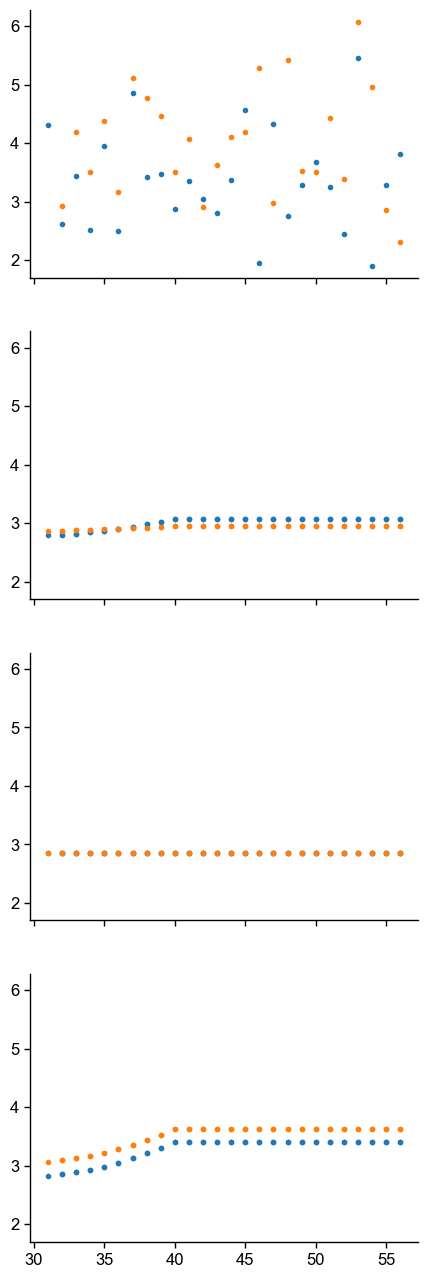

In [ ]:
# get current participant's data
df = df[df["participant"] == participant]

# compute tracking error
df["tracking_error"] = df["righty_pos"] - df["lefty_pos"]
df["tracking_mse"] = df["tracking_error"] ** 2

df["abs_tracking_error"] = df["tracking_error"].abs()

